In [ ]:
import pandas as pd          
import numpy as np           
from sklearn.svm import SVC  
from sklearn.model_selection import StratifiedKFold  
from sklearn.metrics import roc_auc_score  
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')  

# Load Data 
df = pd.read_csv('Assignment_2/residue_contact_data.csv')

X = df.iloc[:, 2:].values  
y = df.iloc[:, 1].values    

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 10-Fold Stratified CV setup 
skfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#  Manual CV Function 
def manual_cv_roc(model, X, y, cv):
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        
        y_proba = model.predict_proba(X_val)[:, 1]
        
        fold_auc = roc_auc_score(y_val, y_proba)
        fold_scores.append(fold_auc)
        
        print(f"   Fold {fold+1:2d} - AUC: {fold_auc:.4f}")
    
    return np.array(fold_scores)

#  Combinations
kernels  = ['linear', 'poly', 'rbf']
C_values = [0.001, 0.01, 0.1]
results  = {}


print("   TASK 1a — SVM WITHOUT SCALING")


for kernel in kernels:
    for C in C_values:
        
        print(f"\nKernel: {kernel.upper()} | C = {C}")
        print("-" * 40)
        
        if kernel == 'poly':
            svm_clf = SVC(kernel='poly', degree=2, C=C,
                          probability=True, random_state=42)
        else:
            svm_clf = SVC(kernel=kernel, C=C,
                          probability=True, random_state=42)
        
        fold_scores = manual_cv_roc(svm_clf, X, y, skfolds)
        
        avg_auc = fold_scores.mean()
        std_auc = fold_scores.std()
        results[f"{kernel}_C{C}"] = avg_auc
        
        print(f"   - Avg ROC-AUC : {avg_auc:.4f}")
        print(f"   - Std Dev     : {std_auc:.4f}")

# Summary Table 
print("   SUMMARY TABLE — Task 1a (No Scaling)")
print(f"{'Kernel':<12} {'C=0.001':>10} {'C=0.01':>10} {'C=0.1':>10}")
for kernel in kernels:
    row = f"{kernel:<12}"
    for C in C_values:
        row += f"  {results[f'{kernel}_C{C}']:>8.4f}"
    print(row)








X shape: (10000, 375)
y shape: (10000,)
   TASK 1a — SVM WITHOUT SCALING

Kernel: LINEAR | C = 0.001
----------------------------------------
   Fold  1 - AUC: 0.8528
   Fold  2 - AUC: 0.8609
   Fold  3 - AUC: 0.8673
   Fold  4 - AUC: 0.8807
   Fold  5 - AUC: 0.8776
   Fold  6 - AUC: 0.8479
   Fold  7 - AUC: 0.8533
   Fold  8 - AUC: 0.8494
   Fold  9 - AUC: 0.8655
   Fold 10 - AUC: 0.8648
   - Avg ROC-AUC : 0.8620
   - Std Dev     : 0.0108

Kernel: LINEAR | C = 0.01
----------------------------------------
   Fold  1 - AUC: 0.8614
   Fold  2 - AUC: 0.8732
   Fold  3 - AUC: 0.8739
   Fold  4 - AUC: 0.8876
   Fold  5 - AUC: 0.8856
   Fold  6 - AUC: 0.8570
   Fold  7 - AUC: 0.8630
   Fold  8 - AUC: 0.8608
   Fold  9 - AUC: 0.8771
   Fold 10 - AUC: 0.8759
   - Avg ROC-AUC : 0.8716
   - Std Dev     : 0.0101

Kernel: LINEAR | C = 0.1
----------------------------------------
   Fold  1 - AUC: 0.8605
   Fold  2 - AUC: 0.8793
   Fold  3 - AUC: 0.8749
   Fold  4 - AUC: 0.8891
   Fold  5 - AUC: 0

NameError: name 'AUC' is not defined

<Figure size 700x500 with 0 Axes>

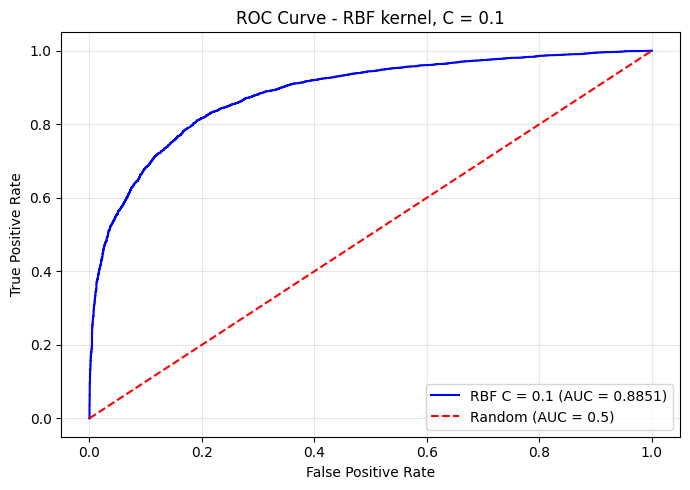

In [23]:
#ROC curve for rbf kernel with c = 0.1

svm_rbf = SVC(kernel = "rbf", C = 0.1, probability = True, random_state = 42)

all_y_true, all_y_prob = [], []

for train_idx, val_idx in skfolds.split(X, y):
    svm_rbf.fit(X[train_idx], y[train_idx])
    all_y_true.extend(y[val_idx])
    all_y_prob.extend(svm_rbf.predict_proba(X[val_idx])[:, 1])

fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
auc = roc_auc_score(all_y_true, all_y_prob)


plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color = 'blue', label = f"RBF C = 0.1 (AUC = {auc:.4f})")
plt.plot([0,1], [0,1], 'r--', label = 'Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RBF kernel, C = 0.1')
plt.legend(loc = 'lower right')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
##SVM with Scaling


#MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_minmax = scaler_mm.fit_transform(X)

results_mm = {}

print("    Task 1b: SVM with MINMAX SCALING ")

for kernel in kernels:
    for C in C_values:

        print(f"\nKernel: {kernel.upper()} | C = {C}")
        print("-" * 40)

        if kernel == "poly":
            svm_clf = SVC(kernel = "poly", degree = 2, C = C, probability = True, random_state = 42)
        else:
            svm_clf = SVC(kernel = kernel,C = C, probability = True, random_state = 42)

        fold_scores = manual_cv_roc(svm_clf, X_minmax, y, skfolds)

        avg_auc = fold_scores.mean()
        std_auc = fold_scores.std()
        results_mm[f"{kernel}_C{C}"] = avg_auc

        print(f"     - Avg ROC-AUC: {avg_auc:.4f}")
        print(f"     - Std Dev  : {std_auc:.4f}")


#Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
X_Standard = scaler_standard.fit_transform(X)

results_std = {}

print("       Task 1b - SVM with Standard Scaler")

for kernel in kernels:
    for C in C_values:

        print(f"\nKernel: {kernel.upper()} | C = {C}")
        print("-" * 40)

        if kernel == "poly":
            svm_clf = SVC(kernel = 'poly', degree = 2, C = C, probability = True, random_state = 42 )
        else:
            svm_clf = SVC(kernel = kernel, C = C, probability = True, random_state = 42)

        fold_scores = manual_cv_roc(svm_clf, X_Standard, y, skfolds)

        avg_auc = fold_scores.mean()
        std_auc = fold_scores.std()
        results_std[f"{kernel}_C{C}"] = avg_auc

        print(f"     - Avg ROC-AUC: {avg_auc:.4f}")
        print(f"     - Std Dev  : {std_auc:.4f}")


    Task 1b: SVM with MINMAX SCALING 

Kernel: LINEAR | C = 0.001
----------------------------------------
   Fold  1 - AUC: 0.7854
   Fold  2 - AUC: 0.8063
   Fold  3 - AUC: 0.8054
   Fold  4 - AUC: 0.8086
   Fold  5 - AUC: 0.8112
   Fold  6 - AUC: 0.8049
   Fold  7 - AUC: 0.7821
   Fold  8 - AUC: 0.7920
   Fold  9 - AUC: 0.7877
   Fold 10 - AUC: 0.8100
     - Avg ROC-AUC: 0.7993
     - Std Dev  : 0.0107

Kernel: LINEAR | C = 0.01
----------------------------------------
   Fold  1 - AUC: 0.8475
   Fold  2 - AUC: 0.8602
   Fold  3 - AUC: 0.8635
   Fold  4 - AUC: 0.8747
   Fold  5 - AUC: 0.8728
   Fold  6 - AUC: 0.8475
   Fold  7 - AUC: 0.8455
   Fold  8 - AUC: 0.8474
   Fold  9 - AUC: 0.8532
   Fold 10 - AUC: 0.8630
     - Avg ROC-AUC: 0.8575
     - Std Dev  : 0.0103

Kernel: LINEAR | C = 0.1
----------------------------------------
   Fold  1 - AUC: 0.8633
   Fold  2 - AUC: 0.8790
   Fold  3 - AUC: 0.8784
   Fold  4 - AUC: 0.8915
   Fold  5 - AUC: 0.8886
   Fold  6 - AUC: 0.8620
   F

In [27]:
#Comparission for MinMax and standard scaler

print("  FINAL COMPARISON — No Scaling vs MinMax vs Standard")
print(f"{'Kernel+C':<16} {'No Scale':>10} {'MinMax':>10} {'Standard':>10}")
print("-" * 55)

for kernel in kernels:
    for C in C_values:
        key = f"{kernel}_C{C}"
        print(f"{key:<16} {results[key]:>10.4f} {results_mm[key]:>10.4f} {results_std[key]:>10.4f}")


  FINAL COMPARISON — No Scaling vs MinMax vs Standard
Kernel+C           No Scale     MinMax   Standard
-------------------------------------------------------
linear_C0.001        0.8620     0.7993     0.8751
linear_C0.01         0.8716     0.8575     0.8741
linear_C0.1          0.8745     0.8744     0.8730
poly_C0.001          0.8268     0.8179     0.6302
poly_C0.01           0.8612     0.8679     0.7220
poly_C0.1            0.8764     0.8754     0.8012
rbf_C0.001           0.8295     0.7710     0.7880
rbf_C0.01            0.8618     0.8259     0.8323
rbf_C0.1             0.8852     0.8774     0.8803


In [37]:
#Task -2: Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, classification_report

#A: Full tree no regularization
dt_full = DecisionTreeClassifier(random_state = 42)
y_pred_full = cross_val_predict(dt_full, X, y, cv = skfolds)

precision_full = precision_score(y,y_pred_full)
recall_full = recall_score(y, y_pred_full)

print("      Tsk 2A - fuLL Decision Tree (No limit)")
print(f"   Precsion : {precision_full: .4f}")
print(f"   Recall :  {recall_full: .4f}")
print("\n Detailed Report:")
print(classification_report(y, y_pred_full, target_names = ['No Contact', 'Contact']))

#B. Max depth = 6
dt_depth6 = DecisionTreeClassifier(max_depth = 6, random_state=42)
y_pred_depth6 = cross_val_predict(dt_depth6, X, y, cv = skfolds)

precision_d6 = precision_score(y, y_pred_depth6)
recall_d6 = recall_score(y, y_pred_depth6)

print("  TASK 2b — Decision Tree (Max Depth = 6)")
print(f"  Precision : {precision_d6:.4f}")
print(f"  Recall    : {recall_d6:.4f}")
print("\nDetailed Report:")
print(classification_report(y, y_pred_depth6, target_names=['No Contact', 'Contact']))


#Comparison
print("  COMPARISON — Full Tree vs Max Depth 6")
print(f"{'':15} {'Full Tree':>12} {'Max Depth 6':>12}")
print("-" * 42)
print(f"{'Precision':<15} {precision_full:>12.4f} {precision_d6:>12.4f}")
print(f"{'Recall':<15} {recall_full:>12.4f} {recall_d6:>12.4f}")

      Tsk 2A - fuLL Decision Tree (No limit)
   Precsion :  0.7167
   Recall :   0.7236

 Detailed Report:
              precision    recall  f1-score   support

  No Contact       0.72      0.71      0.72      5000
     Contact       0.72      0.72      0.72      5000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000

  TASK 2b — Decision Tree (Max Depth = 6)
  Precision : 0.8177
  Recall    : 0.7160

Detailed Report:
              precision    recall  f1-score   support

  No Contact       0.75      0.84      0.79      5000
     Contact       0.82      0.72      0.76      5000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

  COMPARISON — Full Tree vs Max Depth 6
                   Full Tree  Max Depth 6
------------------------------------------
Precision   

In [36]:
# Q3 - Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)

y_pred_rf = cross_val_predict(rf, X, y, cv = skfolds)

precision_rf = precision_score(y, y_pred_rf)
recall_rf = recall_score(y, y_pred_rf)

print("  TASK 3 — Random Forest")
print(f"  Precision : {precision_rf:.4f}")
print(f"  Recall    : {recall_rf:.4f}")
print("\nDetailed Report:")
print(classification_report(y, y_pred_rf,
      target_names=['No Contact', 'Contact']))

# FEATURE Importance
rf.fit(X,y)
importances = rf.feature_importances_
feature_names = df.columns[2:].tolist()
top5_idx = np.argsort(importances)[::-1][:5]
print("  TOP 5 MOST IMPORTANT FEATURES")
print(f"{'Rank':<6} {'Feature Name':<30} {'Importance':>10}")
print("-" * 48)
for rank, idx in enumerate(top5_idx):
    print(f"{rank+1:<6} {feature_names[idx]:<30} {importances[idx]:>10.4f}")



  TASK 3 — Random Forest
  Precision : 0.8199
  Recall    : 0.8014

Detailed Report:
              precision    recall  f1-score   support

  No Contact       0.81      0.82      0.81      5000
     Contact       0.82      0.80      0.81      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

  TOP 5 MOST IMPORTANT FEATURES
Rank   Feature Name                   Importance
------------------------------------------------
1      evfold_f_score_7                   0.0348
2      evfold_coupling_score_12           0.0307
3      gdca score_29                      0.0307
4      gdca score_19                      0.0302
5      evfold_coupling_score_57           0.0277
